Nuestra semilla es la de la alumna Lidia Valera López, con NIA 100522236, por lo que nuestro bank es el 9 (3+6)

Lo primero que hacemos es cargar los datos

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Cargamos los datos
df = pd.read_pickle("bank_09.pkl") 

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Ver número de instancias y variables

In [8]:
n_instancias, n_variables = df.shape

print(f"Número de instancias: {n_instancias}")
print(f"Número de variables: {n_variables}")

Número de instancias: 11000
Número de variables: 17


Ver tipo de variables (si son numéricas, categóricas u ordinales)

In [24]:
tipos = df.dtypes
print(tipos)

num_vars = df.select_dtypes(include=[np.number]).columns
cat_vars = df.select_dtypes(include=['object']).columns
ordinal_vars = ["education"]

cat_vars = [var for var in cat_vars if var not in ordinal_vars]
# Quitar variables ordinales de las variables categóricas

print(f"Variables numéricas: {num_vars}")
print(f"Variables categóricas: {cat_vars}")
print(f"Variables ordinales: {ordinal_vars}")


age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object
Variables numéricas: Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')
Variables categóricas: ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']
Variables ordinales: ['education']


Comprobar categóricas con alta cardinalidad (mas de 10 valores únicos)

In [72]:
for var in df.columns:
    if df[var].nunique() > 10:
        print(f"{var}: {df[var].nunique()} valores únicos")


age: 76 valores únicos
job: 12 valores únicos
balance: 3783 valores únicos
day: 31 valores únicos
month: 12 valores únicos
duration: 1423 valores únicos
campaign: 36 valores únicos
pdays: 472 valores únicos
previous: 34 valores únicos


Ver variables con valores faltantes

In [69]:
for var in df.columns:
    if df[var].isnull().any():
        print(f"{var} con valores nulos")
        break

job con valores nulos


Ver columnas constantes

In [67]:
print("Frecuencias de los valores únicos:")
for var in df.columns:
    value = df[var].value_counts().max() / len(df)
    print(f"{var}: {value:.2f}")
    if value > 0.85:
        print(f"{var} es una variable muy constante")
    if value > 0.99:
        print(f"{var} es una variable constante")

# No se han encontrado variables constantes.

Frecuencias de los valores únicos:
age: 0.04
job: 0.23
marital: 0.56
education: 0.49
default: 0.98
default es una variable muy constante
balance: 0.07
housing: 0.53
loan: 0.87
loan es una variable muy constante
contact: 0.72
day: 0.05
month: 0.25
duration: 0.00
campaign: 0.43
pdays: 0.75
previous: 0.75
poutcome: 0.75
deposit: 0.53


Ver columnas tipo ID

In [73]:
for var in df.columns:
    n = 0
    if df[var].nunique(dropna=False) == len(df):
        print(f"{var} podría ser un ID (todos los valores son únicos)")
        n = 1
if n == 0:
    print("No se han encontrado variables que podrían ser IDs (todos los valores son únicos).")


No se han encontrado variables que podrían ser IDs (todos los valores son únicos).


Ver si es un problema de clasificación o regresión

In [81]:

target = "deposit"
print(df[target].dtype)
print(df[target].nunique(), "valores únicos")

#El target presenta dos valores únicos lo que supone un problema de clasificación binaria.
#  Además, el target es de tipo object, lo que indica que es una variable categórica.
#  Esto sugiere que el modelo a utilizar para predecir el target debe ser un modelo de clasificación, 
# como por ejemplo un árbol de decisión, una regresión logística o una red neuronal.

object
2 valores únicos


Ver si está balanceado

deposit
no     5780
yes    5220
Name: count, dtype: int64

deposit
no     0.525455
yes    0.474545
Name: proportion, dtype: float64


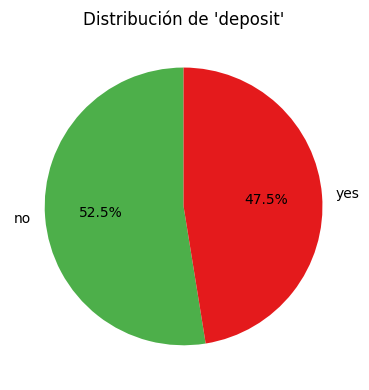

In [ ]:
counts = df[target].value_counts()
props = df[target].value_counts(normalize=True)

print(counts)
print()
print(props)

# Gráfico pie para visualizar la distribución del target
plt.figure(figsize=(4, 4))
counts.plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4daf4a", "#e41a1c"],
    legend=False,
    ylabel=""
)
plt.title("Distribución de deposit")
plt.tight_layout()
plt.show()

Analizar pdays

count    11000.000000
mean        51.308636
std        108.782842
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.250000
max        854.000000
Name: pdays, dtype: float64

Número de clientes no contactados (pdays = -1): 8203
Número de clientes contactados (pdays != -1): 2797

Proporción de no contactados: 0.7457272727272727
Proporción de contactados: 0.25427272727272726


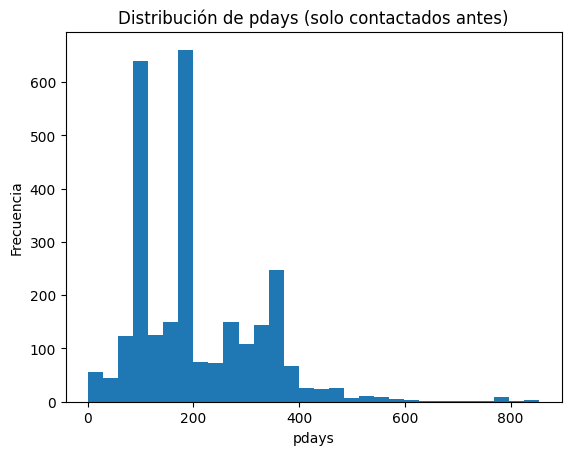

In [103]:
target = "pdays"

# Estadísticas generales
print(df[target].describe())
print()

# Número de clientes no contactados (pdays = -1) vs contactados (pdays != -1)
n_not_contacted = (df[target] == -1).sum()
n_contacted = (df[target] != -1).sum()

print("Número de clientes no contactados (pdays = -1):", n_not_contacted)
print("Número de clientes contactados (pdays != -1):", n_contacted)

# Opcional: comparación de proporciones
print()
print("Proporción de no contactados:", n_not_contacted / len(df))
print("Proporción de contactados:", n_contacted / len(df))

# Histograma de pdays para los contactados (pdays != -1)
import matplotlib.pyplot as plt

pdays_contacted = df.loc[df[target] != -1, target]
plt.hist(pdays_contacted, bins=30)
plt.title("Distribución de pdays (solo contactados antes)")
plt.xlabel("pdays")
plt.ylabel("Frecuencia")
plt.show()
